In [1]:
!pip install -q --upgrade pip
!pip install -q efficientnet

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import efficientnet.tfkeras as efn
import seaborn as sns

from kaggle_datasets import KaggleDatasets
from keras.applications import ResNet50

from tensorflow.keras.mixed_precision import experimental as mixed_precision
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix

import sys
import glob
import math
import gc
import time

print(f'tensorflow version: {tf.__version__}')
print(f'tensorflow keras version: {tf.keras.__version__}')
print(f'python version: P{sys.version}')

tensorflow version: 2.4.1
tensorflow keras version: 2.4.0
python version: P3.7.9 | packaged by conda-forge | (default, Feb 13 2021, 20:03:11) 
[GCC 9.3.0]


In [3]:
AUTO = tf.data.experimental.AUTOTUNE
# Detect hardware, return appropriate distribution strategy
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # TPU detection. No parameters necessary if TPU_NAME environment variable is set. On Kaggle this is always the case.
    print('Running on TPU ', tpu.master())
except ValueError:
    tpu = None

if tpu:
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
else:
    strategy = tf.distribute.get_strategy() # default distribution strategy in Tensorflow. Works on CPU and single GPU.

REPLICAS = strategy.num_replicas_in_sync
print(f'REPLICAS: {REPLICAS}')

# # set half precision policy
mixed_precision.set_policy('mixed_bfloat16')

# enable XLA optmizations
tf.config.optimizer.set_jit(True)

print(f'Compute dtype: {mixed_precision.global_policy().compute_dtype}')
print(f'Variable dtype: {mixed_precision.global_policy().variable_dtype}')

Running on TPU  grpc://10.0.0.2:8470
REPLICAS: 8
Compute dtype: bfloat16
Variable dtype: float32


In [4]:
IMG_HEIGHT = 600
IMG_WIDTH = 800

IMG_SIZE = 600
IMG_TARGET_SIZE = 512
N_CHANNELS = 3

N_TRAIN_IMGS = 21642
N_VAL_IMGS = 5410
BATCH_SIZE_VAL = 128 * REPLICAS # 5410 / 8 / 4

N_LABELS = 5
N_FOLDS = 5
EPOCHS = 30

BATCH_SIZE_BASE = 16
BATCH_SIZE = BATCH_SIZE_BASE * REPLICAS

TARGET_DTYPE = tf.bfloat16

# ImageNet mean and standard deviation
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

In [5]:
GCS_DS_PATH = KaggleDatasets().get_gcs_path('cassava-leaf-disease-tfrecords-600x600')

In [6]:
def decode_tfrecord_train(record_bytes):
    features = tf.io.parse_single_example(record_bytes, {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64),
        'height': tf.io.FixedLenFeature([], tf.int64),
        'width': tf.io.FixedLenFeature([], tf.int64),
    })
    
    height = features['height']
    width = features['width']

    image = tf.io.decode_jpeg(features['image'])
    image = tf.reshape(image, [height, width, N_CHANNELS])
    
    # get random square
    if height > width:
        offset = tf.random.uniform(shape=(), minval=0, maxval=height-width, dtype=tf.int64)
        image = tf.slice(image, [offset, 0, 0], [width, width, N_CHANNELS])
    elif width > height:
        offset = tf.random.uniform(shape=(), minval=0, maxval=width-height, dtype=tf.int64)
        image = tf.slice(image, [0, offset, 0], [height, height, N_CHANNELS])
    else:
        image = tf.slice(image, [0, 0, 0], [height, width, N_CHANNELS])
        
    size = tf.cast(height if height < width else width, tf.float32)
    
    # cast label to int8
    label = tf.cast(features['label'], tf.uint8)

    return image, label, size

In [7]:
# chance of x in y to return true, used for conditional data augmentation
def chance(x, y):
    return tf.random.uniform(shape=[], minval=0, maxval=y, dtype=tf.int32) < x

In [8]:
def augment_image(image, label, size):
    # random flip image horizontally
    image = tf.image.random_flip_left_right(image)
    # random flip image vertically
    image = tf.image.random_flip_up_down(image)
    
    # random transpose
    if chance(1,2):
        image = tf.image.transpose(image)
    
    # random crop between 75%-100%
    crop_size = tf.random.uniform(shape=(), minval=size*0.75, maxval=size)
    image = tf.image.random_crop(image, [crop_size, crop_size, N_CHANNELS])
    
    # cast to target dtype and resize
    image = tf.image.resize(image, [IMG_TARGET_SIZE, IMG_TARGET_SIZE])
    
    # normalize according to imagenet mean and std
    image /= 255.0
    image = (image - IMAGENET_MEAN) / IMAGENET_STD
    
    # one hot encode label
    label = tf.one_hot(label, N_LABELS, dtype=tf.float32)
    
    return image, label

def read_augment_image(record_bytes):
    image, label, size = decode_tfrecord_train(record_bytes)
    image, label = augment_image(image, label, size)
    
    return image, label

def get_mix_img_idx(labels_idxs, idx):
    idx_candidates = tf.where(labels_idxs != idx)
    r = tf.random.uniform(minval=0, maxval=len(idx_candidates), shape=[], dtype=tf.int32)
    idx = tf.gather(idx_candidates, r)
    idx = tf.cast(idx, tf.int32)
    idx = tf.squeeze(idx)
    
    return idx

# Mixup Implementation

In [9]:
def mixup(images, labels, alpha=0.40):
    l = len(images)
    # get image factors
    a = tfp.distributions.Beta(alpha, alpha).sample(l)
    a_label = tf.reshape(a, shape=(l,1))
    a_label = tf.tile(a_label, [1, N_LABELS])
    b_label = 1 - a_label
    
    a_image = tf.reshape(a, shape=(l,1,1,1))
    a_image = tf.tile(a_image, [1, IMG_TARGET_SIZE, IMG_TARGET_SIZE ,N_CHANNELS])
    a_image = tf.cast(a_image, tf.float32)
    b_image = 1 - a_image
    
    # get mixup image indices
    if l == 2:
        idxs = tf.constant([1, 0])
    else:
        labels_idxs = tf.range(len(labels))
        idxs = tf.map_fn(lambda idx: get_mix_img_idx(labels_idxs, idx), tf.range(len(labels)))
    
    images_mixup = tf.gather(images, idxs)
    labels_mixup = tf.gather(labels, idxs)
    
    # mixup images and labels
    images =  images * a_image + images_mixup * b_image
    labels = labels * a_label + labels_mixup * b_label
    
    images = tf.cast(images, TARGET_DTYPE)
    
    return images, labels

# Cutmix

In [10]:
def create_cutmix_mask(a):
    # create random mask size and coordinates
    r_w = tf.cast(IMG_TARGET_SIZE * tf.math.sqrt(1 - a), tf.int32)
    r_h = tf.cast(IMG_TARGET_SIZE * tf.math.sqrt(1 - a), tf.int32)
    
    if r_w == IMG_TARGET_SIZE:
        r_x = 0
    else:
        r_x = tf.random.uniform(minval=0, maxval=IMG_TARGET_SIZE - r_w, shape=[], dtype=tf.int32)
        
    if r_h == IMG_TARGET_SIZE:
        r_y = 0
    else:
        r_y = tf.random.uniform(minval=0, maxval=IMG_TARGET_SIZE - r_w, shape=[], dtype=tf.int32)

    # compute padding sizes
    pad_left = r_x
    pad_right = IMG_TARGET_SIZE - (r_x + r_w)
    pad_top = r_y
    pad_bottom = IMG_TARGET_SIZE - (r_y + r_h)
    
    # create mask_a and mask_b
    mask_a = tf.ones(shape=[r_w, r_h], dtype=tf.float32)
    mask_a = tf.pad(mask_a, [[pad_left, pad_right], [pad_top, pad_bottom]], mode='CONSTANT', constant_values=0)
    mask_a = tf.expand_dims(mask_a, axis=2)
    
    return mask_a

def cutmix(images, labels):
    l = len(images)
    a_float32 = tfp.distributions.Beta(1.0, 1.0).sample([l])

    mask_b = tf.map_fn(create_cutmix_mask, a_float32)
    mask_a = tf.math.abs(mask_b - 1)
    
    # images_idxs
    if l == 2:
        idxs = tf.constant([1, 0])
    else:
        labels_idxs = tf.range(len(labels))
        idxs = tf.map_fn(lambda idx: get_mix_img_idx(labels_idxs, idx), tf.range(len(labels)))
    
    images_cutmix = tf.gather(images, idxs)
    labels_cutmix = tf.gather(labels, idxs)
    
    a_float32_labels = tf.expand_dims(a_float32, axis=1)
    a_float32_labels = tf.repeat(a_float32_labels, N_LABELS, axis=1)
    labels_factor = a_float32_labels
    labels_cutmix_factor = 1 - a_float32_labels
    
    # cutmix images and labels
    images = images * mask_a + images_cutmix * mask_b
    labels = labels * labels_factor + labels_cutmix * labels_cutmix_factor
    
    images = tf.cast(images, TARGET_DTYPE)
    
    return images, labels

# Gridmask

In [11]:
def gridmask(images, labels):
    l = len(images)
    
    d = tf.random.uniform(minval=int(IMG_TARGET_SIZE * (96/224)), maxval=IMG_TARGET_SIZE, shape=[], dtype=tf.int32)
    grid = tf.constant([[[0], [1]],[[1], [0]]], dtype=tf.float32)
    grid = tf.image.resize(grid, [d, d], method='nearest')
    
    # 50% chance to rotate mask
    if chance(1, 2):
        grid = tf.image.rot90(grid, 1)

    repeats = IMG_TARGET_SIZE // d + 1
    grid = tf.tile(grid, multiples=[repeats, repeats, 1])
    grid = tf.image.random_crop(grid, [IMG_TARGET_SIZE, IMG_TARGET_SIZE, 1])
    grid = tf.expand_dims(grid, axis=0)
    grid = tf.tile(grid, multiples=[l, 1, 1, 1])

    images = images * grid
    images = tf.cast(images, TARGET_DTYPE)
    
    return images, labels

In [12]:
def augment_batch(images, labels, augmentations=None):
    if augmentations is None:
        r = tf.random.uniform(minval=0, maxval=4, shape=[], dtype=tf.int32)
    else:
        r = tf.random.uniform(minval=0, maxval=len(augmentations), shape=[], dtype=tf.int32)
        r = tf.gather(augmentations, r)
        
    if r == 0:
        images = tf.cast(images, TARGET_DTYPE)
        return images, labels
    elif r == 1:
        return mixup(images, labels)
    elif r == 2:
        return cutmix(images, labels)
    elif r == 3:
        return gridmask(images, labels)
    else:
        images = tf.cast(images, TARGET_DTYPE)
        return images, labels

In [13]:
def reshape_batch(images, labels):
    images = tf.reshape(images, shape=[BATCH_SIZE, IMG_TARGET_SIZE, IMG_TARGET_SIZE, N_CHANNELS])
    labels = tf.reshape(labels, shape=[BATCH_SIZE, N_LABELS])
    
    random_idxs = tf.random.shuffle(tf.range(BATCH_SIZE))
    images = tf.gather(images, random_idxs)
    labels = tf.gather(labels, random_idxs)
    
    return images, labels

In [14]:
def get_train_dataset(bs=BATCH_SIZE, fold=0, augmentations=None):
    ignore_order = tf.data.Options()
    ignore_order.experimental_deterministic = False
    
    FNAMES_TRAIN_TFRECORDS = tf.io.gfile.glob(f'{GCS_DS_PATH}/fold_{fold}/train/*.tfrecords')
    train_dataset = tf.data.TFRecordDataset(FNAMES_TRAIN_TFRECORDS, num_parallel_reads=AUTO)
    train_dataset = train_dataset.with_options(ignore_order)
    train_dataset = train_dataset.prefetch(AUTO)
    train_dataset = train_dataset.repeat()
    train_dataset = train_dataset.map(read_augment_image, num_parallel_calls=AUTO)

    train_dataset = train_dataset.batch(BATCH_SIZE_BASE)
    train_dataset = train_dataset.map(lambda images, labels: augment_batch(images, labels, augmentations=augmentations), num_parallel_calls=REPLICAS)
    
    train_dataset = train_dataset.batch(REPLICAS)
    train_dataset = train_dataset.map(reshape_batch, num_parallel_calls=1)
    
    train_dataset = train_dataset.prefetch(1)
    
    return train_dataset

train_dataset = get_train_dataset()

In [15]:
def benchmark(num_epochs=3, n_steps_per_epoch=10, augmentations=None, bs=BATCH_SIZE):
    dataset = get_train_dataset(augmentations=augmentations)
    start_time = time.perf_counter()
    for epoch_num in range(num_epochs):
        epoch_start = time.perf_counter()
        for idx, (images, labels) in enumerate(dataset.take(n_steps_per_epoch)):
            if idx is 1:
                print(images.shape, labels.shape)
            pass
        print(f'epoch {epoch_num} took: {round(time.perf_counter() - epoch_start, 2)}')
    print("Execution time:", round(time.perf_counter() - start_time, 2))
    
benchmark(num_epochs=3, augmentations=[2,3])

(128, 512, 512, 3) (128, 5)
epoch 0 took: 4.71
(128, 512, 512, 3) (128, 5)
epoch 1 took: 2.06
(128, 512, 512, 3) (128, 5)
epoch 2 took: 2.07
Execution time: 8.84


Validation dataset

In [16]:
def resize_image(image, label, size):
    image = tf.image.resize(image, [IMG_TARGET_SIZE, IMG_TARGET_SIZE])
    
    return image, label, tf.cast(IMG_TARGET_SIZE, tf.float32)

In [17]:
def decode_tfrecord_val(record_bytes):
    features = tf.io.parse_single_example(record_bytes, {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64),
        'height': tf.io.FixedLenFeature([], tf.int64),
        'width': tf.io.FixedLenFeature([], tf.int64),
    })
    
    height = features['height']
    width = features['width']

    image = tf.io.decode_jpeg(features['image'])
    image = tf.reshape(image, [height, width, N_CHANNELS])
    
    # get random square
    if height > width:
        offset = (height - width) // 2
        image = tf.slice(image, [offset, 0, 0], [width, width, N_CHANNELS])
    elif width > height:
        offset = (width - height) // 2
        image = tf.slice(image, [0, offset, 0], [height, height, N_CHANNELS])
    else:
        image = tf.slice(image, [0, 0, 0], [height, width, N_CHANNELS])
    
    # resize to target size
    image = tf.image.resize(image, [IMG_TARGET_SIZE, IMG_TARGET_SIZE])
    
    # normalize according to imagenet mean and std
    image /= 255.0
    image = (image - IMAGENET_MEAN) / IMAGENET_STD
    
    # cast to TARGET_DTYPE
    image = tf.cast(image, TARGET_DTYPE)
    
    label = tf.cast(features['label'], tf.int32)
    
    # one hot encode label
    label = tf.one_hot(label, N_LABELS, dtype=tf.int32)
    
    return image, label

In [18]:
def get_val_dataset(bs=BATCH_SIZE, fold=0):
    FNAMES_VAL_TFRECORDS = tf.io.gfile.glob(f'{GCS_DS_PATH}/fold_{fold}/val/*.tfrecords')
    val_dataset = tf.data.TFRecordDataset(FNAMES_VAL_TFRECORDS, num_parallel_reads=AUTO)
    val_dataset = val_dataset.prefetch(BATCH_SIZE_VAL)
    val_dataset = val_dataset.repeat()
    val_dataset = val_dataset.map(decode_tfrecord_val, num_parallel_calls=AUTO)
    val_dataset = val_dataset.batch(bs, drop_remainder=True)
    val_dataset = val_dataset.prefetch(1)
    
    return val_dataset

val_dataset = get_val_dataset()

# Lr scheduler

In [19]:
def lrfn(epoch, bs=BATCH_SIZE, epochs=EPOCHS):
    # Config
    LR_START = 1e-6
    LR_MAX = 2e-4
    LR_FINAL = 1e-6
    LR_RAMPUP_EPOCHS = 4
    LR_SUSTAIN_EPOCHS = 0
    DECAY_EPOCHS = epochs  - LR_RAMPUP_EPOCHS - LR_SUSTAIN_EPOCHS - 1
    LR_EXP_DECAY = (LR_FINAL / LR_MAX) ** (1 / (EPOCHS - LR_RAMPUP_EPOCHS - LR_SUSTAIN_EPOCHS - 1))

    if epoch < LR_RAMPUP_EPOCHS: # exponential warmup
        lr = LR_START + (LR_MAX + LR_START) * (epoch / LR_RAMPUP_EPOCHS) ** 2.5
    elif epoch < LR_RAMPUP_EPOCHS + LR_SUSTAIN_EPOCHS: # sustain lr
        lr = LR_MAX
    else: # cosine decay
        epoch_diff = epoch - LR_RAMPUP_EPOCHS - LR_SUSTAIN_EPOCHS
        decay_factor = (epoch_diff / DECAY_EPOCHS) * math.pi
        decay_factor= (tf.math.cos(decay_factor).numpy() + 1) / 2        
        lr = LR_FINAL + (LR_MAX - LR_FINAL) * decay_factor

    return lr

def lrfn2(epoch):
    
    LR_START = 0.00001
    LR_MAX = 0.00005 * strategy.num_replicas_in_sync
    LR_MIN = 0.00001
    LR_RAMPUP_EPOCHS = 4
    LR_SUSTAIN_EPOCHS = 4
    LR_EXP_DECAY = .8

    if epoch < LR_RAMPUP_EPOCHS:
        lr = (LR_MAX - LR_START) / LR_RAMPUP_EPOCHS * epoch + LR_START
    elif epoch < LR_RAMPUP_EPOCHS + LR_SUSTAIN_EPOCHS:
        lr = LR_MAX
    else:
        lr = (LR_MAX - LR_MIN) * LR_EXP_DECAY**(epoch - LR_RAMPUP_EPOCHS - LR_SUSTAIN_EPOCHS) + LR_MIN
    return lr
    


# Using Binary and Categorical focal loss

In [20]:
from tensorflow.keras import backend as K
import dill


def binary_focal_loss(gamma=2., alpha=.25):
    """
    Binary form of focal loss.
      FL(p_t) = -alpha * (1 - p_t)**gamma * log(p_t)
      where p = sigmoid(x), p_t = p or 1 - p depending on if the label is 1 or 0, respectively.
    References:
        https://arxiv.org/pdf/1708.02002.pdf
    Usage:
     model.compile(loss=[binary_focal_loss(alpha=.25, gamma=2)], metrics=["accuracy"], optimizer=adam)
    """
    def binary_focal_loss_fixed(y_true, y_pred):
        """
        :param y_true: A tensor of the same shape as `y_pred`
        :param y_pred:  A tensor resulting from a sigmoid
        :return: Output tensor.
        """
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))

        epsilon = K.epsilon()
        # clip to prevent NaN's and Inf's
        pt_1 = K.clip(pt_1, epsilon, 1. - epsilon)
        pt_0 = K.clip(pt_0, epsilon, 1. - epsilon)

        return -K.sum(alpha * K.pow(1. - pt_1, gamma) * K.log(pt_1)) \
               -K.sum((1 - alpha) * K.pow(pt_0, gamma) * K.log(1. - pt_0))

    return binary_focal_loss_fixed


def categorical_focal_loss(gamma=2., alpha=.25):
    """
    Softmax version of focal loss.
           m
      FL = ∑  -alpha * (1 - p_o,c)^gamma * y_o,c * log(p_o,c)
          c=1
      where m = number of classes, c = class and o = observation
    Parameters:
      alpha -- the same as weighing factor in balanced cross entropy
      gamma -- focusing parameter for modulating factor (1-p)
    Default value:
      gamma -- 2.0 as mentioned in the paper
      alpha -- 0.25 as mentioned in the paper
    References:
        Official paper: https://arxiv.org/pdf/1708.02002.pdf
        https://www.tensorflow.org/api_docs/python/tf/keras/backend/categorical_crossentropy
    Usage:
     model.compile(loss=[categorical_focal_loss(alpha=.25, gamma=2)], metrics=["accuracy"], optimizer=adam)
    """
    def categorical_focal_loss_fixed(y_true, y_pred):
        """
        :param y_true: A tensor of the same shape as `y_pred`
        :param y_pred: A tensor resulting from a softmax
        :return: Output tensor.
        """

        # Scale predictions so that the class probas of each sample sum to 1
        y_pred /= K.sum(y_pred, axis=-1, keepdims=True)

        # Clip the prediction value to prevent NaN's and Inf's
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        
        tf.cast(y_pred, tf.float32)
        tf.cast(y_true, tf.float32)
        # Calculate Cross Entropy
        cross_entropy = -y_true * K.log(y_pred)
        print(f'type of y_pred ---- {type(y_pred)}')
        print(f'type of y_true ---- {type(y_true)}')

        # Calculate Focal Loss
        loss = alpha * K.pow(1 - y_pred, gamma) * cross_entropy

        print(f'type of k_sum ---- {type(K.sum(loss, axis=1))}')
        tf.cast(loss, tf.float32)
        # Sum the losses in mini_batch
        return_list = K.sum(loss, axis=1)
        
        tf.cast(return_list, tf.float32)
#         return K.sum(loss, axis=1)
        return return_list

    return categorical_focal_loss_fixed

# Model

In [21]:
def get_model(choice):
    # reset to free memory and training variables
    tf.keras.backend.clear_session()
    
    
    net = net_choices.get(choice)
    with strategy.scope():
        
        
        if (choice==0):
            net = efn.EfficientNetB4(
                include_top=False,
                weights='noisy-student',
                input_shape=(IMG_TARGET_SIZE, IMG_TARGET_SIZE, N_CHANNELS),
            )
        elif (choice==1):
            net = ResNet50(
                weights='imagenet',
                include_top=False,
            )
        elif (choice==2):
            net=tf.keras.applications.DenseNet201(
                weights='imagenet',
                include_top=False

            )
        
        for layer in reversed(net.layers):
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False
                
            else:
                layer.trainable = True
        
        model = tf.keras.Sequential([
            net,
            tf.keras.layers.Dropout(0.45),
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dropout(0.45),
            tf.keras.layers.Dense(N_LABELS, activation='softmax', dtype=tf.float32),
        ])

        # add metrics
        metrics = [
            tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
            tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy'),
        ]

        optimizer = tf.keras.optimizers.Adam()
        loss = tf.keras.losses.CategoricalCrossentropy()
        cat_loss = categorical_focal_loss(gamma=2., alpha=.25)
        
        model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
#         model.summary()
        return model

# Validation function

In [22]:
def show_validation_report_per_class(model, dataset, steps, name, bs):
    print(f'--- {name} REPORT ---')
    # classification report
    y = np.ndarray(shape=steps * bs, dtype=np.uint16)
    y_pred = np.ndarray(shape=steps * bs, dtype=np.uint16)
    for idx, (images, labels) in tqdm(enumerate(dataset.take(steps)), total=steps):
        with tf.device('cpu:0'):
            y[idx*bs:(idx+1)*bs] = np.argmax(labels, axis=1)
            y_pred[idx*bs:(idx+1)*bs] = np.argmax(model.predict(images).astype(np.float32), axis=1)
            
    print(classification_report(y, y_pred))
    
    # Confusion matrix
    fig, ax = plt.subplots(1, 1, figsize=(20, 12))
    cfn_matrix = confusion_matrix(y, y_pred, labels=range(N_LABELS))
    cfn_matrix = (cfn_matrix.T / cfn_matrix.sum(axis=1)).T
    df_cm = pd.DataFrame(cfn_matrix, index=np.arange(N_LABELS), columns=np.arange(N_LABELS))
    ax = sns.heatmap(df_cm, cmap='Blues', annot=True, fmt='.3f', linewidths=.7, annot_kws={'size':14}).set_title(f'{name} CONFUSION MATRIX')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel('PREDICTED', fontsize=24, labelpad=10)
    plt.ylabel('ACTUAL', fontsize=24, labelpad=10)
    plt.show()

# Plotting curves function

In [23]:
def plot_history_metric(history, metric):
    TRAIN_EPOCHS = len(history.history['loss'])
    x = np.arange(TRAIN_EPOCHS)
    x_axis_labels = list(map(str, np.arange(1, TRAIN_EPOCHS+1)))
    val = 'val' in ''.join(history.history.keys())
    # summarize history for accuracy
    plt.figure(figsize=(20, 10))
    plt.plot(history.history[metric])
    if val:
        plt.plot(history.history[f'val_{metric}'])
    
    plt.title(f'Model {metric}', fontsize=30)
    plt.ylabel(metric, fontsize=26)
    plt.yticks(fontsize=20)
    plt.xlabel('epoch', fontsize=26)
    plt.xticks(x, x_axis_labels, fontsize=16) # set tick step to 1 and let x axis start at 1
    plt.legend(['train'] + ['test'] if val else [], loc='upper left')
    plt.grid()
    plt.show()

# Running model

TRAINING FOR 30 EPOCHS WITH BATCH SIZE 128

TRAIN IMAGES: 21642, VAL IMAGES: 5410

74842112/74836368 [==============================] - 1s 0us/step
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
densenet201 (Functional)     (None, None, None, 1920)  18321984  
_________________________________________________________________
dropout (Dropout)            (None, None, None, 1920)  0         
_________________________________________________________________
global_average_pooling2d (Gl (None, 1920)              0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 1920)              0         
_________________________________________________________________
dense (Dense)                (None, 5)                 9605      
Total params: 18,331,589
Trainable params: 17,873,477
Non-trainable params: 458,112
______________________

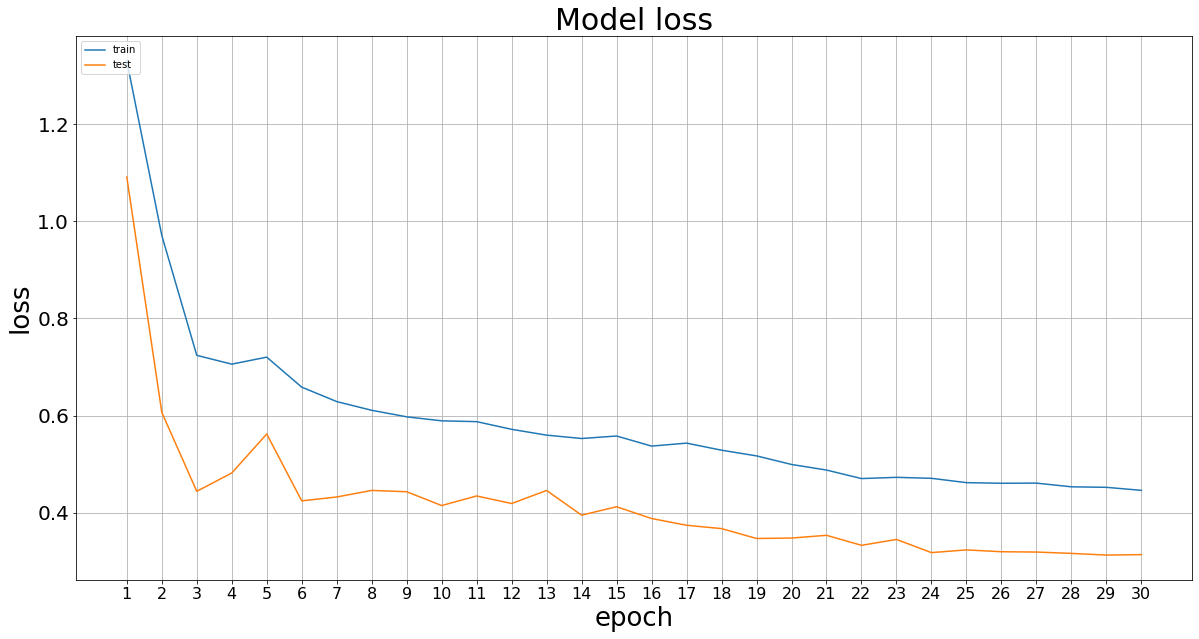

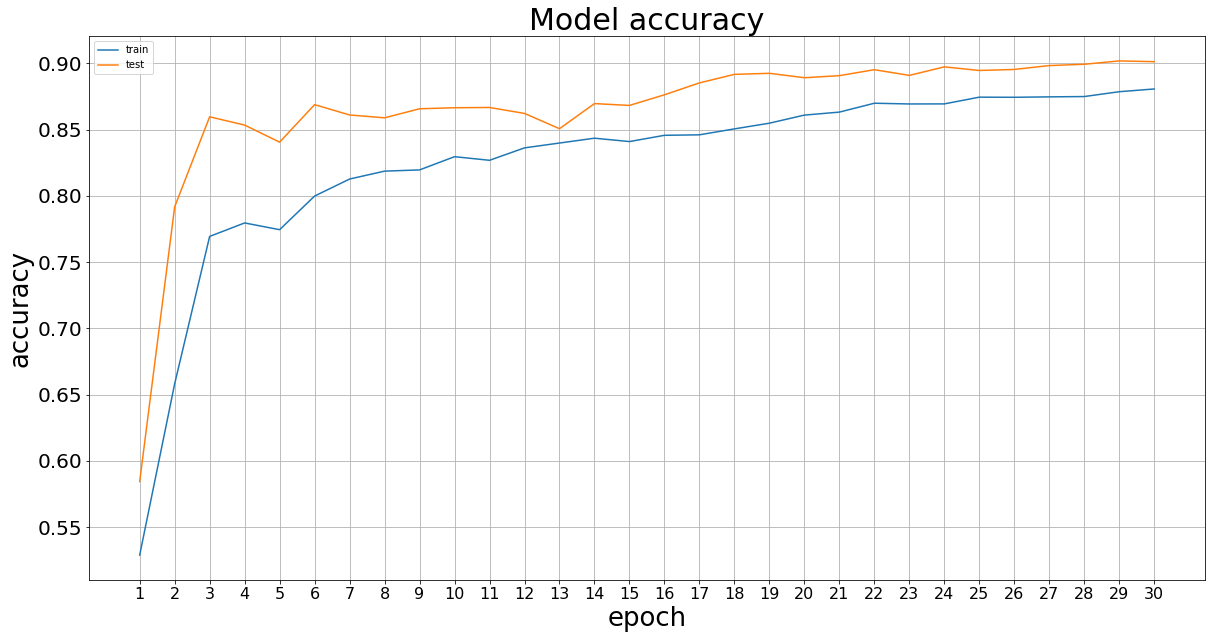

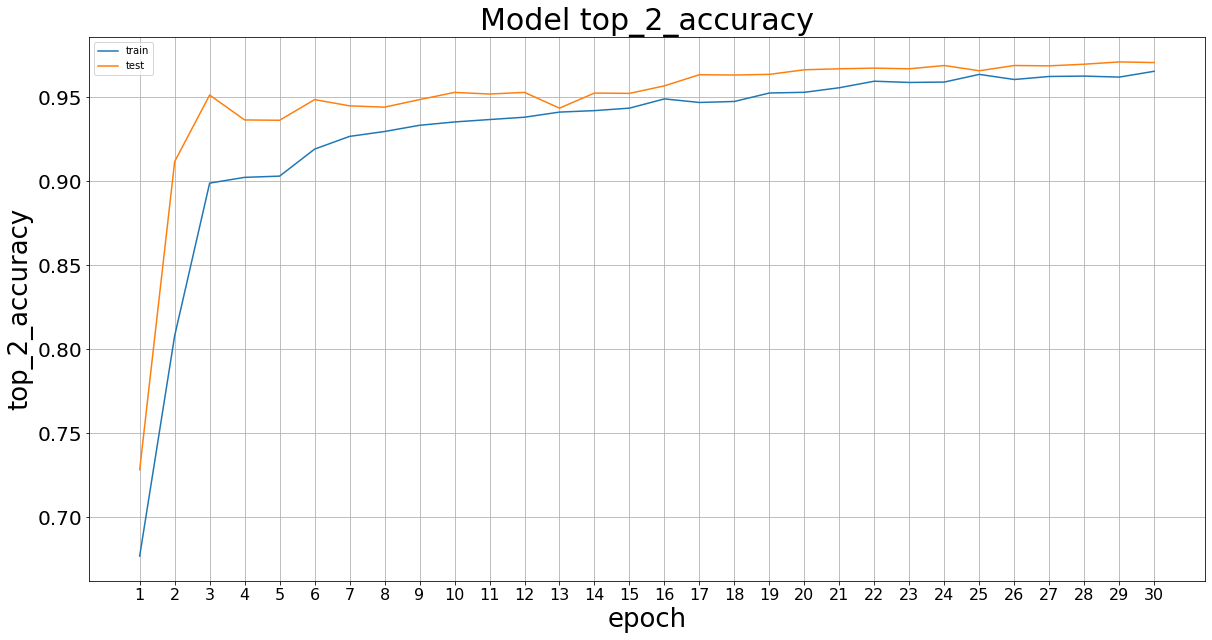

--- VALIDATION REPORT ---


  0%|          | 0/5 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       0.73      0.69      0.71       291
           1       0.87      0.86      0.87       677
           2       0.87      0.81      0.84       607
           3       0.95      0.98      0.96      2992
           4       0.77      0.76      0.76       553

    accuracy                           0.90      5120
   macro avg       0.84      0.82      0.83      5120
weighted avg       0.90      0.90      0.90      5120



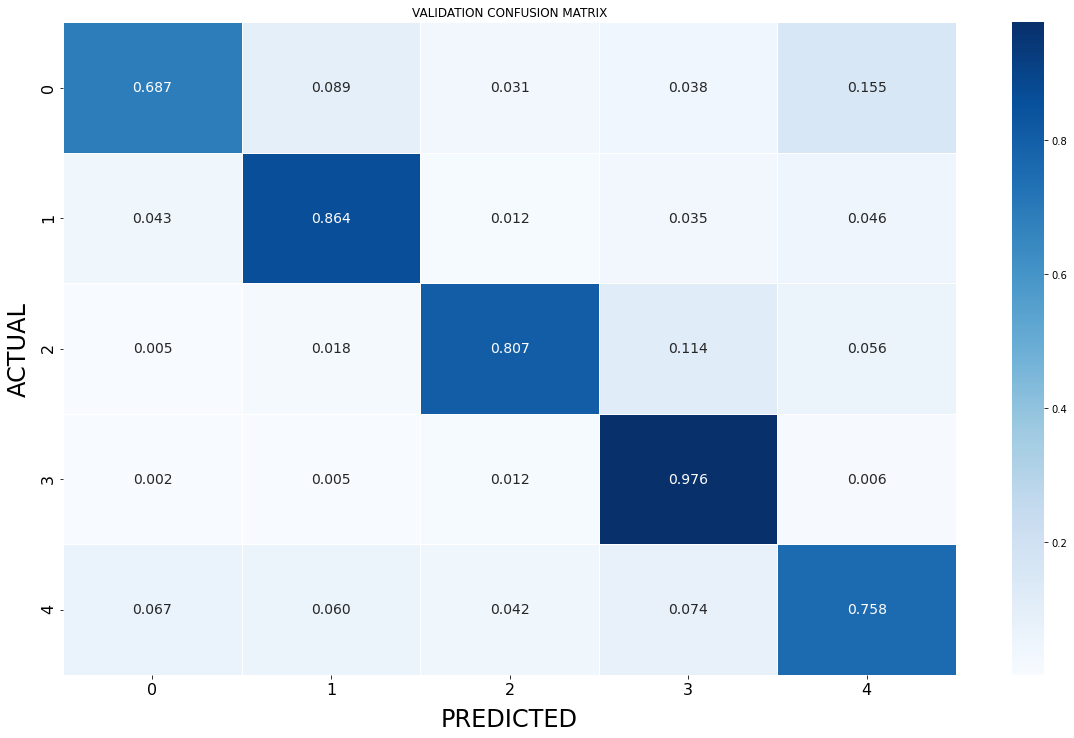



************************* augmentations [2, 3] ************************* 

fold: 1, epochs: 30
CutMix AND GridMask 

Epoch 1/30

Epoch 00001: LearningRateScheduler reducing learning rate to 1e-06.
169/169 [==============================] - 181s 541ms/step - loss: 1.5196 - accuracy: 0.4224 - top_2_accuracy: 0.5760 - val_loss: 1.0830 - val_accuracy: 0.5900 - val_top_2_accuracy: 0.7514
Epoch 2/30

Epoch 00002: LearningRateScheduler reducing learning rate to 7.28125e-06.
169/169 [==============================] - 48s 286ms/step - loss: 1.0642 - accuracy: 0.6193 - top_2_accuracy: 0.7729 - val_loss: 0.6042 - val_accuracy: 0.7850 - val_top_2_accuracy: 0.9164
Epoch 3/30

Epoch 00003: LearningRateScheduler reducing learning rate to 3.6532115754624014e-05.
169/169 [==============================] - 49s 290ms/step - loss: 0.7851 - accuracy: 0.7425 - top_2_accuracy: 0.8845 - val_loss: 0.4845 - val_accuracy: 0.8391 - val_top_2_accuracy: 0.9402
Epoch 4/30

Epoch 00004: LearningRateScheduler reduci

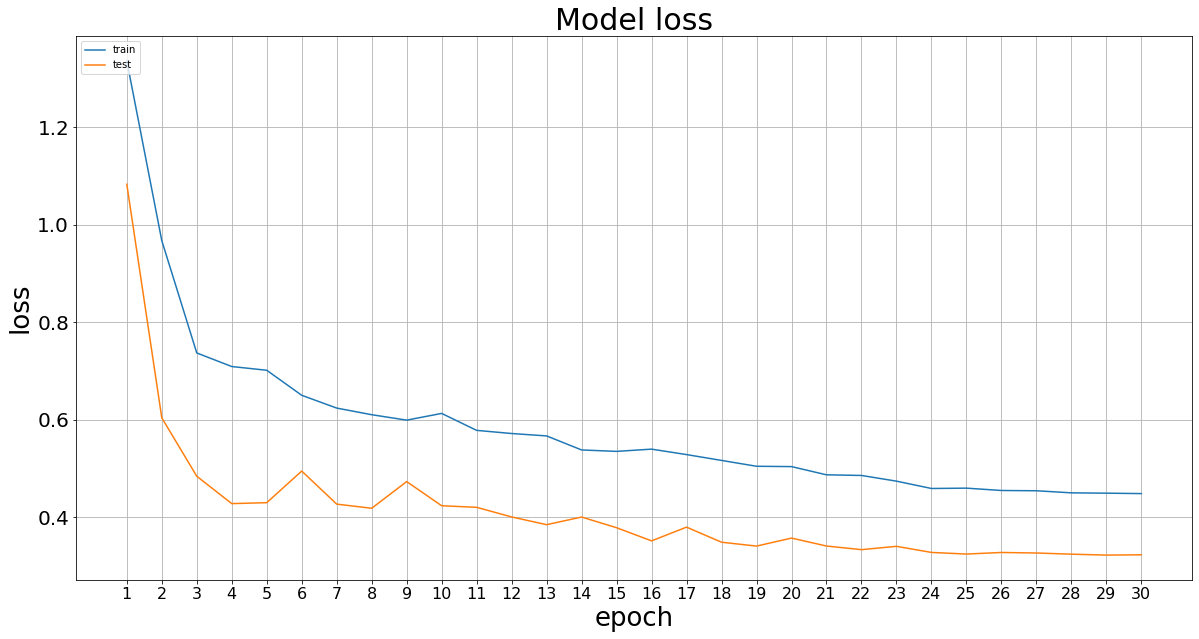

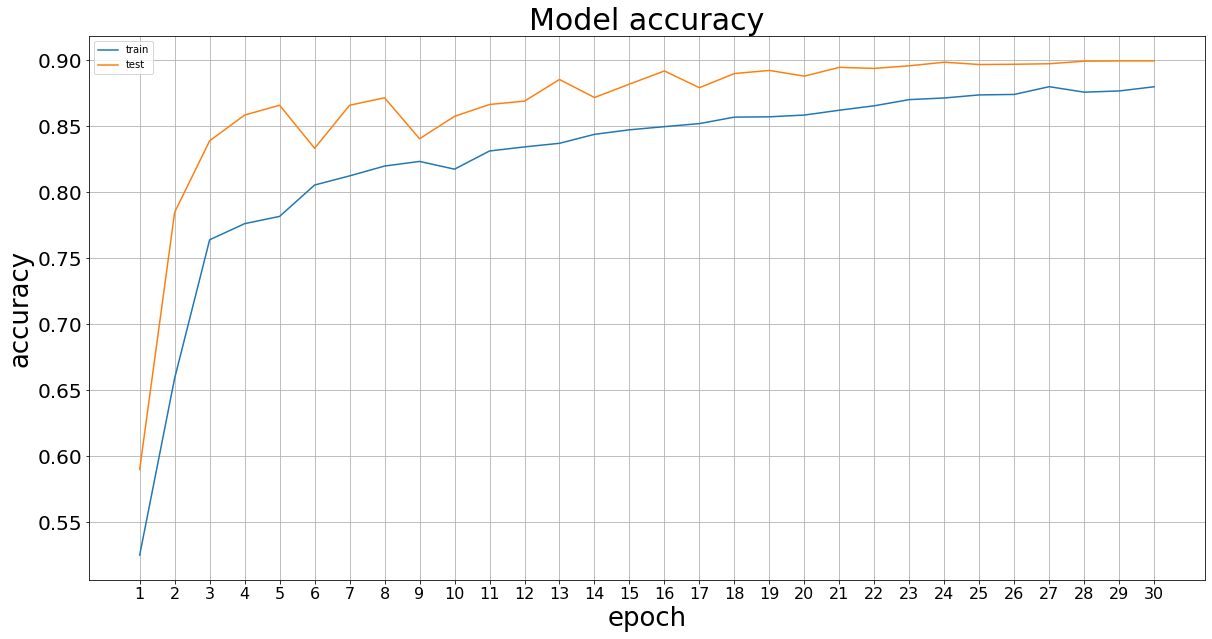

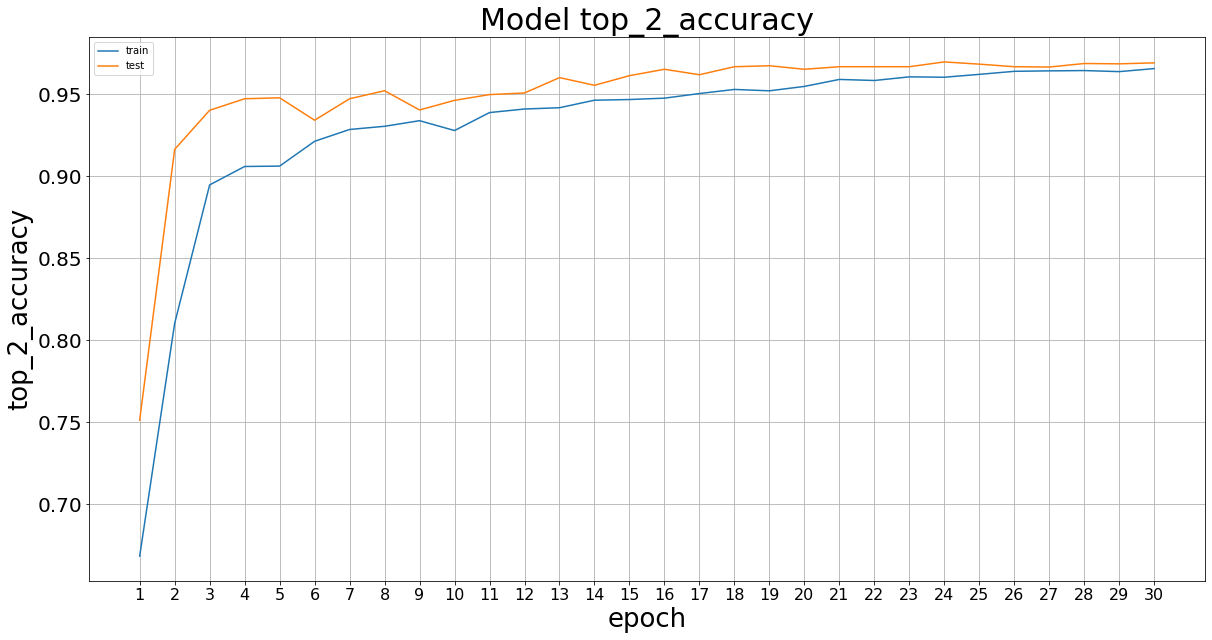

--- VALIDATION REPORT ---


  0%|          | 0/5 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       0.67      0.68      0.68       288
           1       0.85      0.83      0.84       676
           2       0.90      0.79      0.84       606
           3       0.96      0.98      0.97      3000
           4       0.76      0.79      0.77       550

    accuracy                           0.90      5120
   macro avg       0.83      0.81      0.82      5120
weighted avg       0.90      0.90      0.90      5120



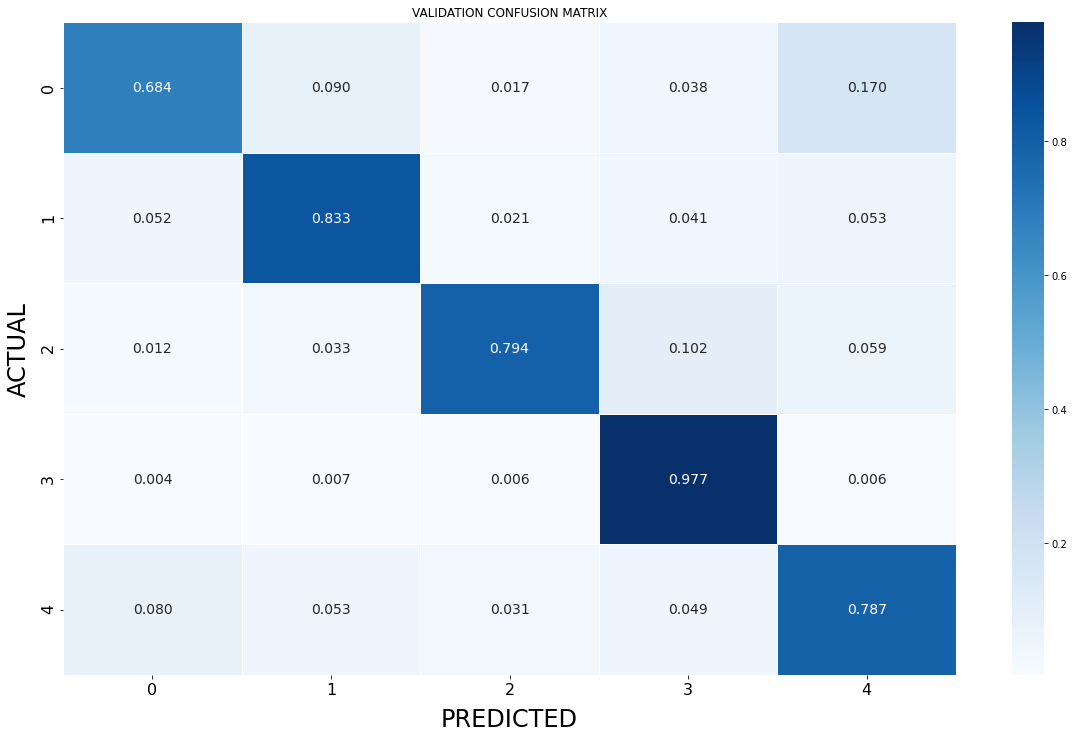



************************* augmentations [2, 3] ************************* 

fold: 2, epochs: 30
CutMix AND GridMask 

Epoch 1/30

Epoch 00001: LearningRateScheduler reducing learning rate to 1e-06.
169/169 [==============================] - 182s 580ms/step - loss: 1.5095 - accuracy: 0.4140 - top_2_accuracy: 0.6021 - val_loss: 1.1084 - val_accuracy: 0.5840 - val_top_2_accuracy: 0.7404
Epoch 2/30

Epoch 00002: LearningRateScheduler reducing learning rate to 7.28125e-06.
169/169 [==============================] - 48s 286ms/step - loss: 1.0626 - accuracy: 0.6177 - top_2_accuracy: 0.7735 - val_loss: 0.6306 - val_accuracy: 0.7719 - val_top_2_accuracy: 0.9045
Epoch 3/30

Epoch 00003: LearningRateScheduler reducing learning rate to 3.6532115754624014e-05.
169/169 [==============================] - 48s 285ms/step - loss: 0.7806 - accuracy: 0.7402 - top_2_accuracy: 0.8799 - val_loss: 0.4923 - val_accuracy: 0.8465 - val_top_2_accuracy: 0.9428
Epoch 4/30

Epoch 00004: LearningRateScheduler reduci

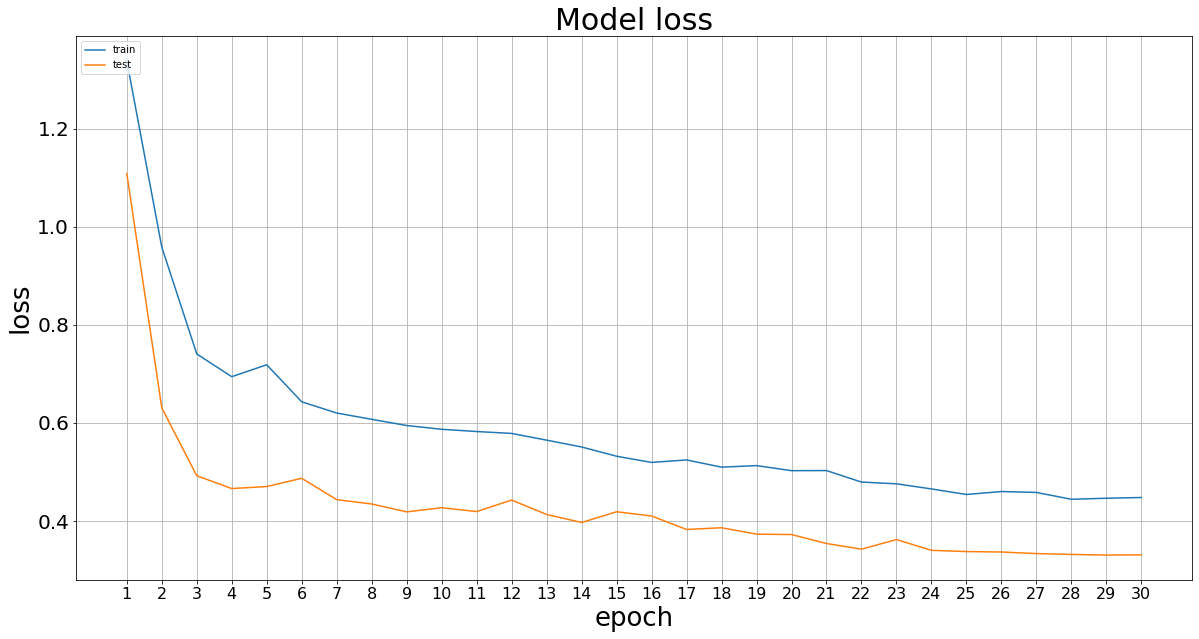

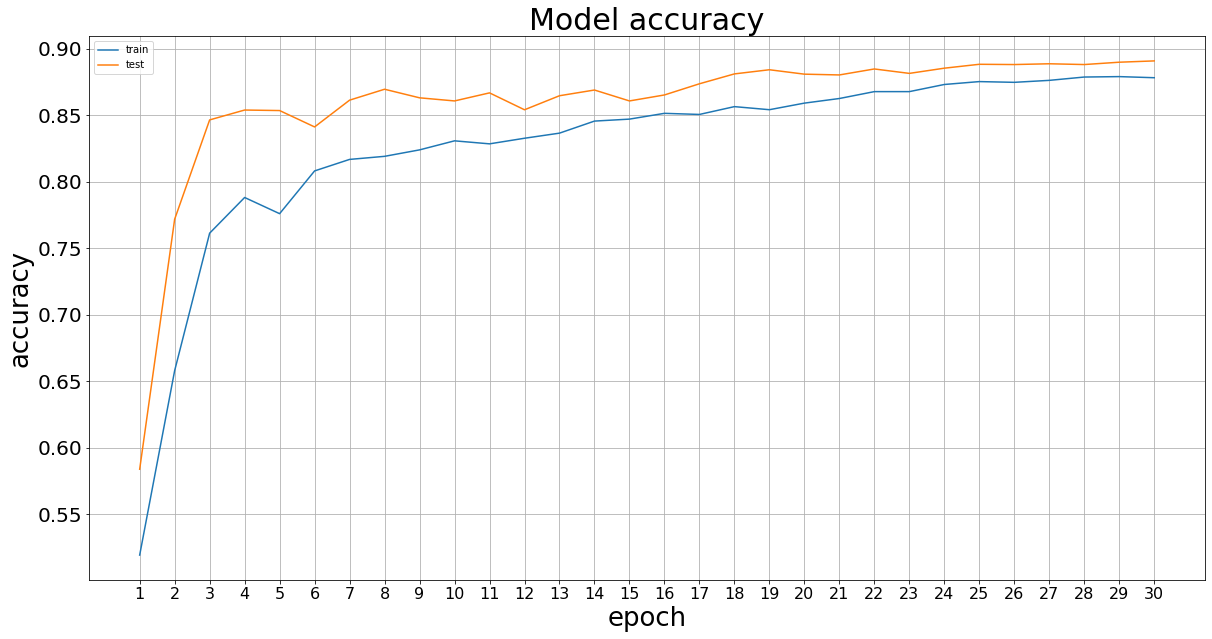

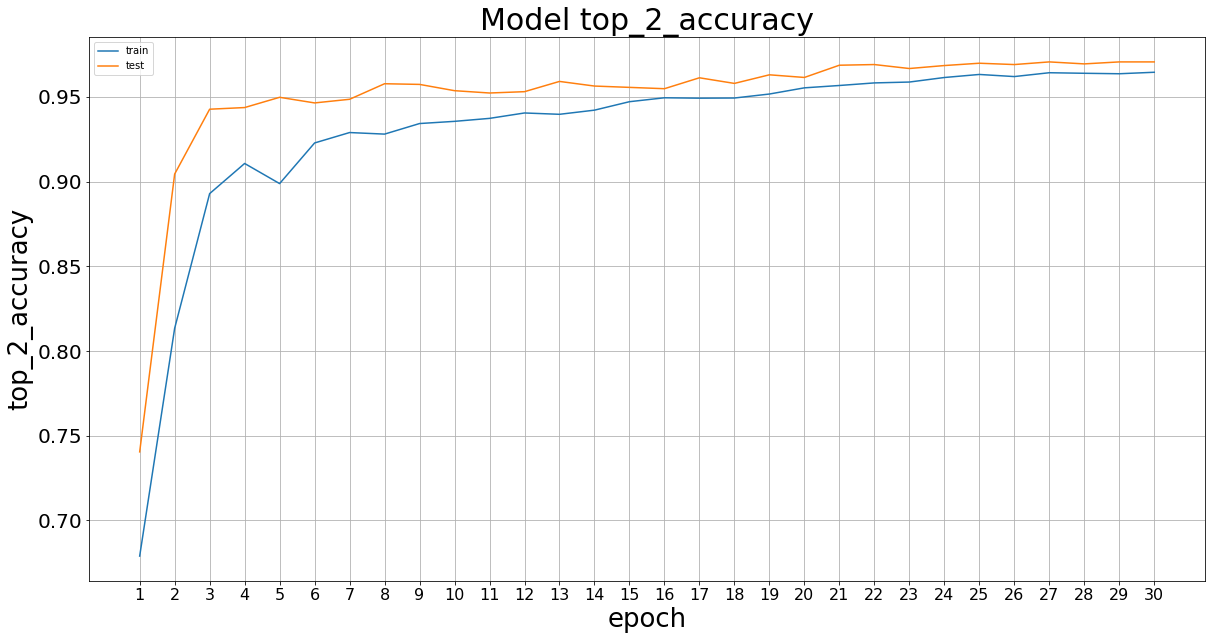

--- VALIDATION REPORT ---


  0%|          | 0/5 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       0.65      0.59      0.62       293
           1       0.85      0.84      0.85       688
           2       0.88      0.80      0.84       605
           3       0.95      0.97      0.96      2989
           4       0.75      0.76      0.75       545

    accuracy                           0.89      5120
   macro avg       0.81      0.79      0.80      5120
weighted avg       0.89      0.89      0.89      5120



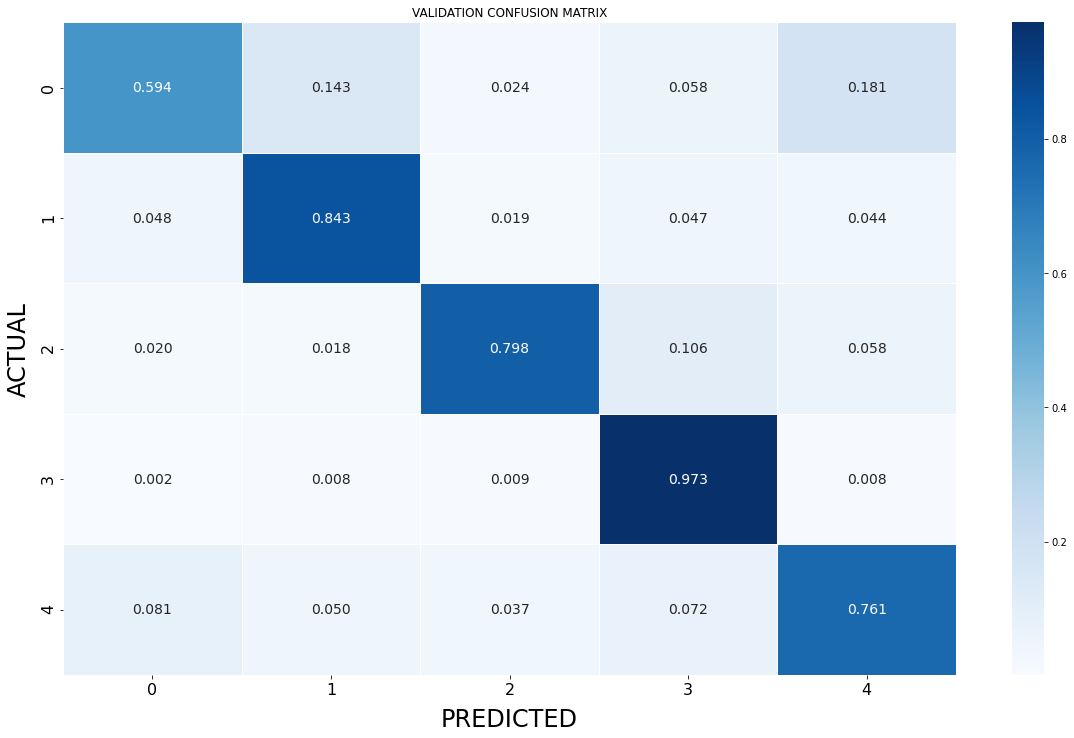



************************* augmentations [2, 3] ************************* 

fold: 3, epochs: 30
CutMix AND GridMask 

Epoch 1/30

Epoch 00001: LearningRateScheduler reducing learning rate to 1e-06.
169/169 [==============================] - 177s 554ms/step - loss: 1.4576 - accuracy: 0.4488 - top_2_accuracy: 0.5950 - val_loss: 1.0929 - val_accuracy: 0.5855 - val_top_2_accuracy: 0.7598
Epoch 2/30

Epoch 00002: LearningRateScheduler reducing learning rate to 7.28125e-06.
169/169 [==============================] - 48s 284ms/step - loss: 1.0326 - accuracy: 0.6321 - top_2_accuracy: 0.7814 - val_loss: 0.5983 - val_accuracy: 0.7830 - val_top_2_accuracy: 0.9002
Epoch 3/30

Epoch 00003: LearningRateScheduler reducing learning rate to 3.6532115754624014e-05.
169/169 [==============================] - 48s 286ms/step - loss: 0.8046 - accuracy: 0.7322 - top_2_accuracy: 0.8738 - val_loss: 0.4630 - val_accuracy: 0.8461 - val_top_2_accuracy: 0.9416
Epoch 4/30

Epoch 00004: LearningRateScheduler reduci

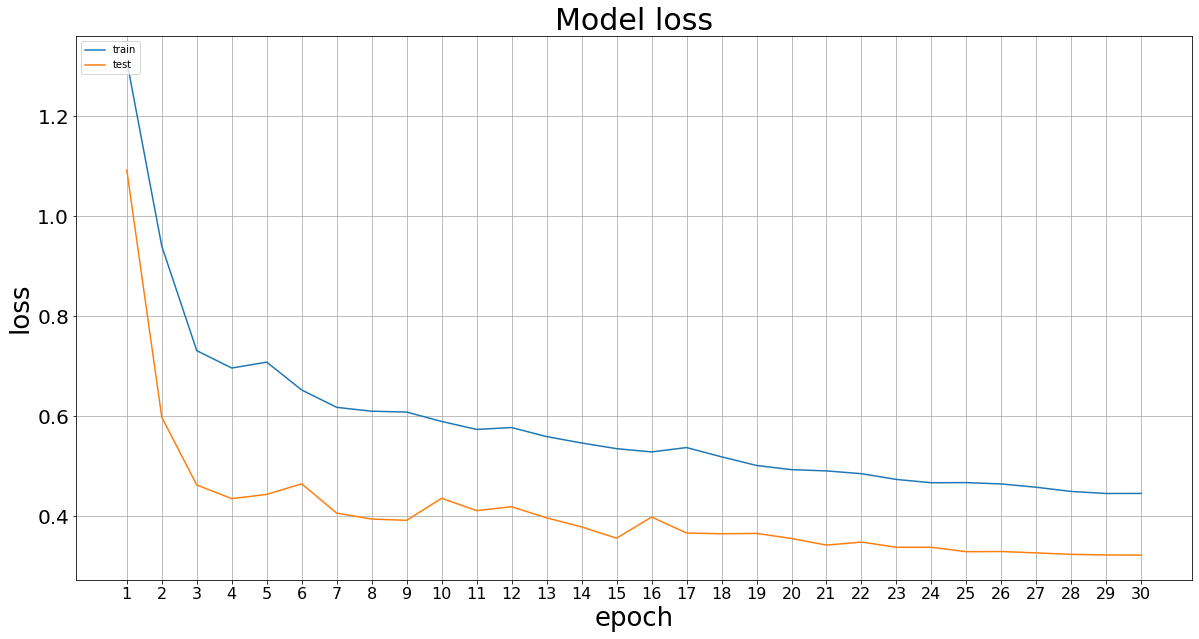

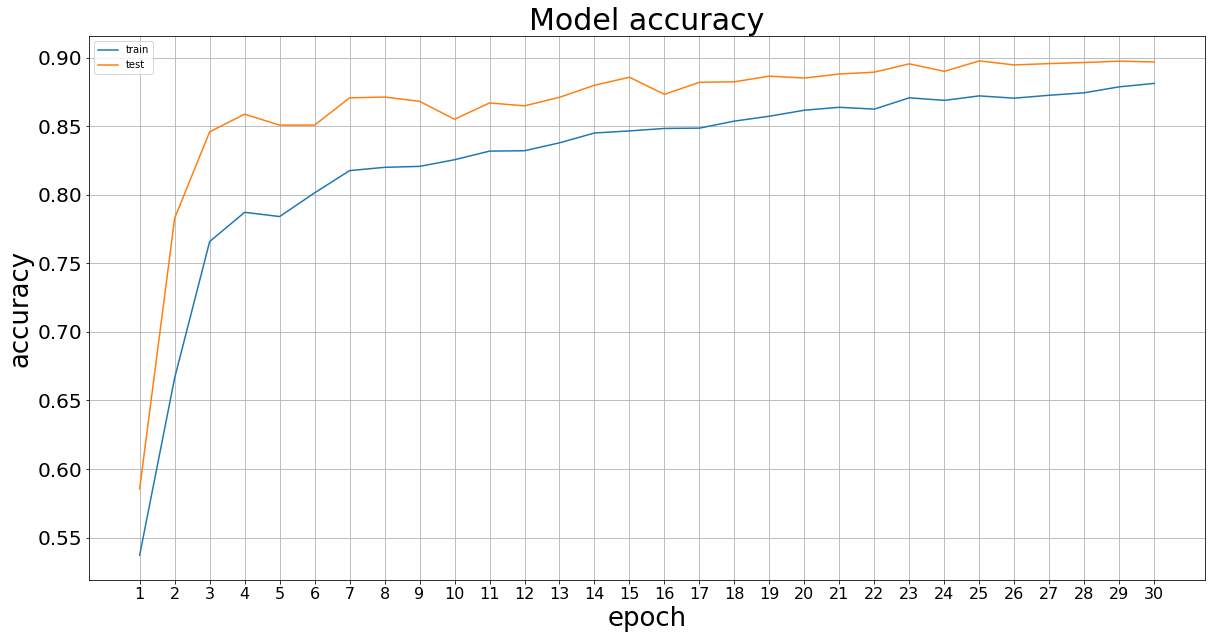

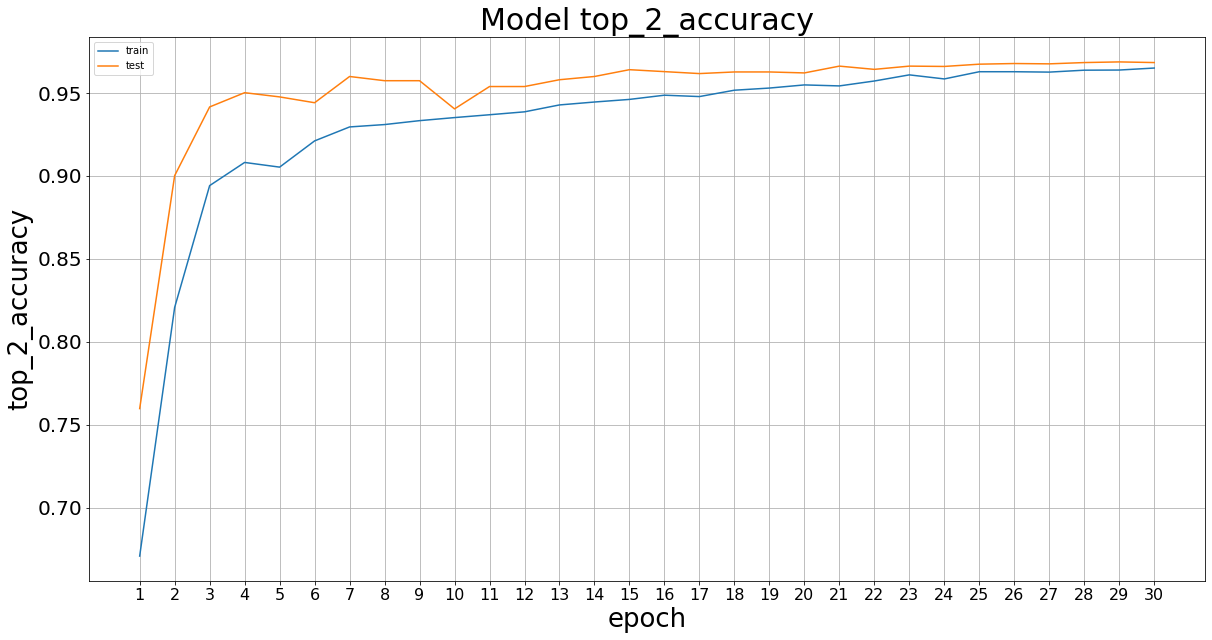

--- VALIDATION REPORT ---


  0%|          | 0/5 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       0.75      0.68      0.71       295
           1       0.86      0.86      0.86       684
           2       0.86      0.82      0.84       600
           3       0.95      0.97      0.96      2997
           4       0.76      0.77      0.77       544

    accuracy                           0.90      5120
   macro avg       0.83      0.82      0.83      5120
weighted avg       0.90      0.90      0.90      5120



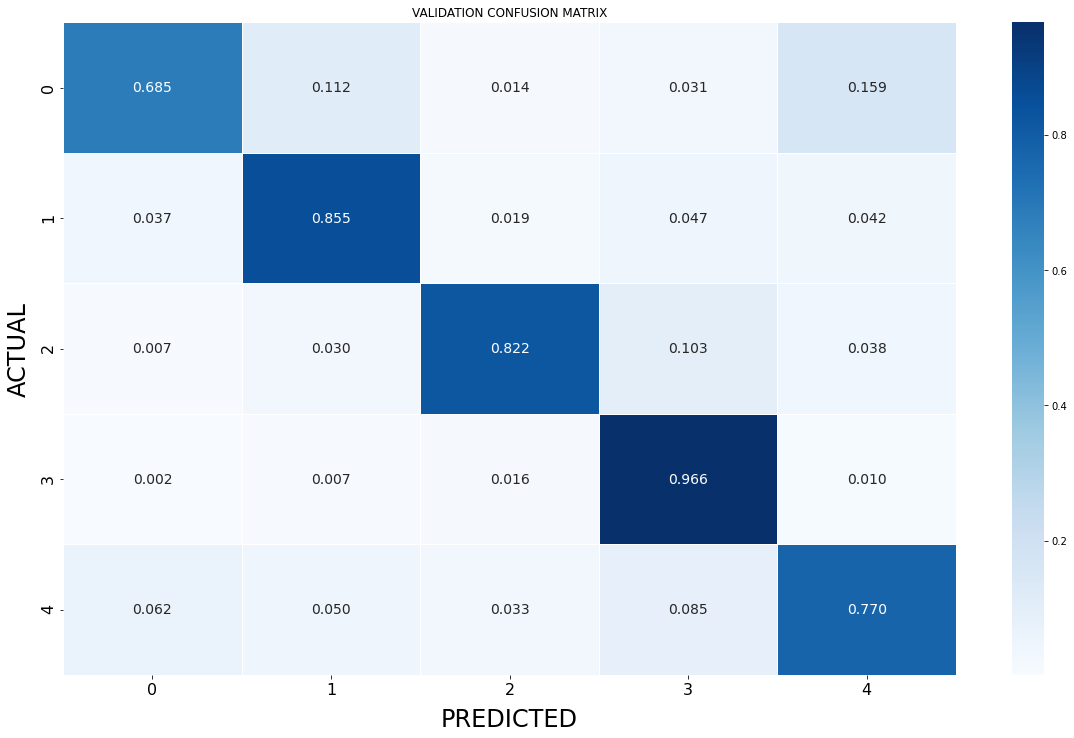



************************* augmentations [2, 3] ************************* 

fold: 4, epochs: 30
CutMix AND GridMask 

Epoch 1/30

Epoch 00001: LearningRateScheduler reducing learning rate to 1e-06.
169/169 [==============================] - 176s 542ms/step - loss: 1.4080 - accuracy: 0.4779 - top_2_accuracy: 0.6582 - val_loss: 1.0923 - val_accuracy: 0.5826 - val_top_2_accuracy: 0.7555
Epoch 2/30

Epoch 00002: LearningRateScheduler reducing learning rate to 7.28125e-06.
169/169 [==============================] - 48s 286ms/step - loss: 1.0368 - accuracy: 0.6281 - top_2_accuracy: 0.7789 - val_loss: 0.6249 - val_accuracy: 0.7748 - val_top_2_accuracy: 0.9109
Epoch 3/30

Epoch 00003: LearningRateScheduler reducing learning rate to 3.6532115754624014e-05.
169/169 [==============================] - 48s 285ms/step - loss: 0.7748 - accuracy: 0.7502 - top_2_accuracy: 0.8842 - val_loss: 0.4933 - val_accuracy: 0.8463 - val_top_2_accuracy: 0.9385
Epoch 4/30

Epoch 00004: LearningRateScheduler reduci

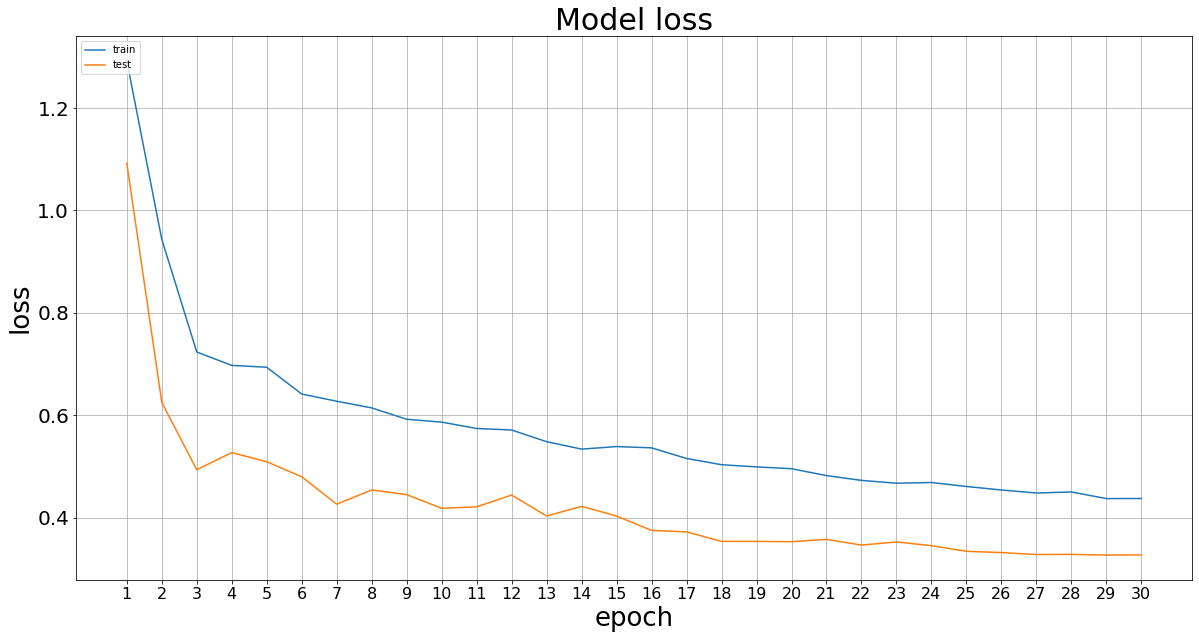

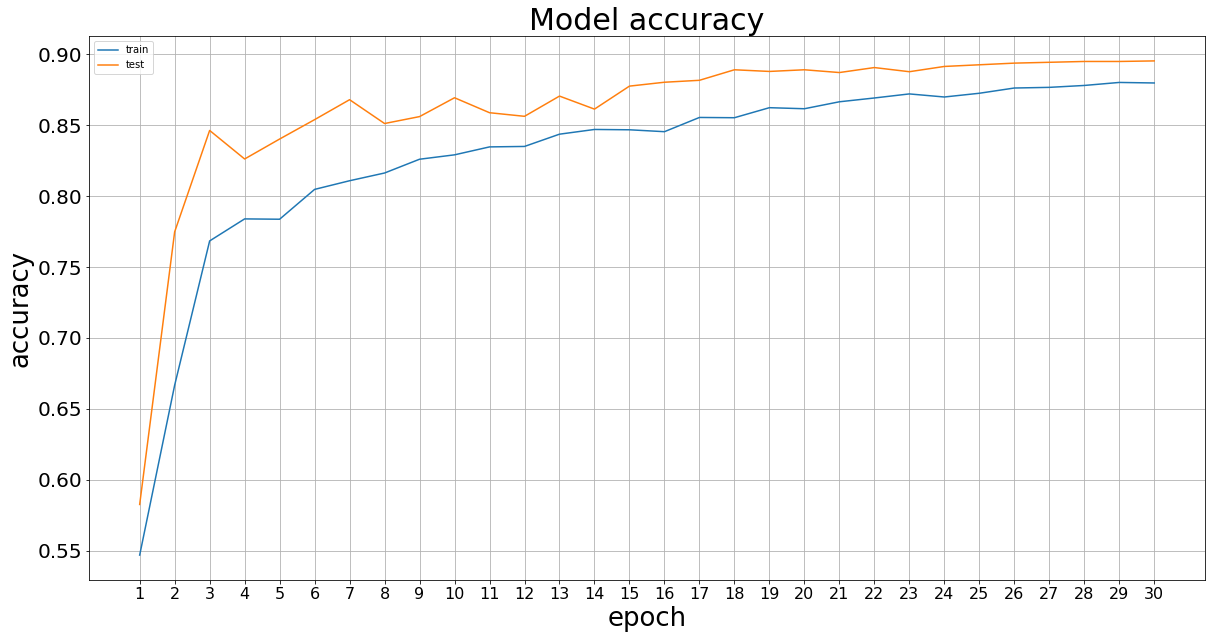

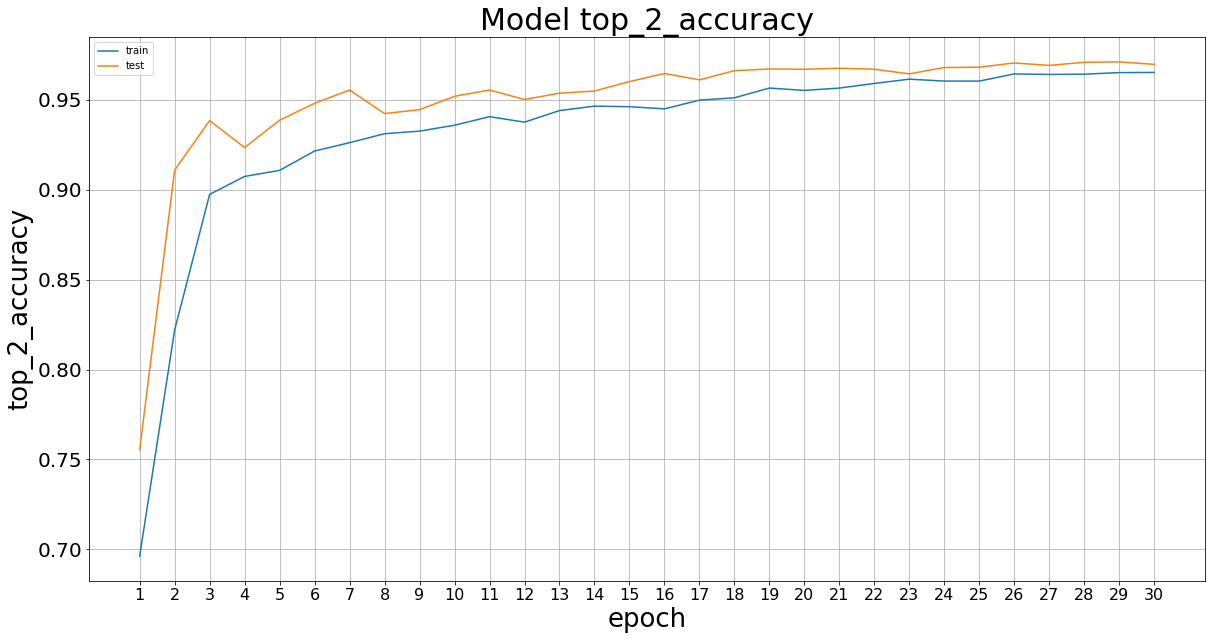

--- VALIDATION REPORT ---


  0%|          | 0/5 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       0.68      0.61      0.64       302
           1       0.85      0.85      0.85       700
           2       0.85      0.81      0.83       589
           3       0.95      0.97      0.96      2981
           4       0.79      0.78      0.79       548

    accuracy                           0.90      5120
   macro avg       0.82      0.80      0.81      5120
weighted avg       0.89      0.90      0.89      5120



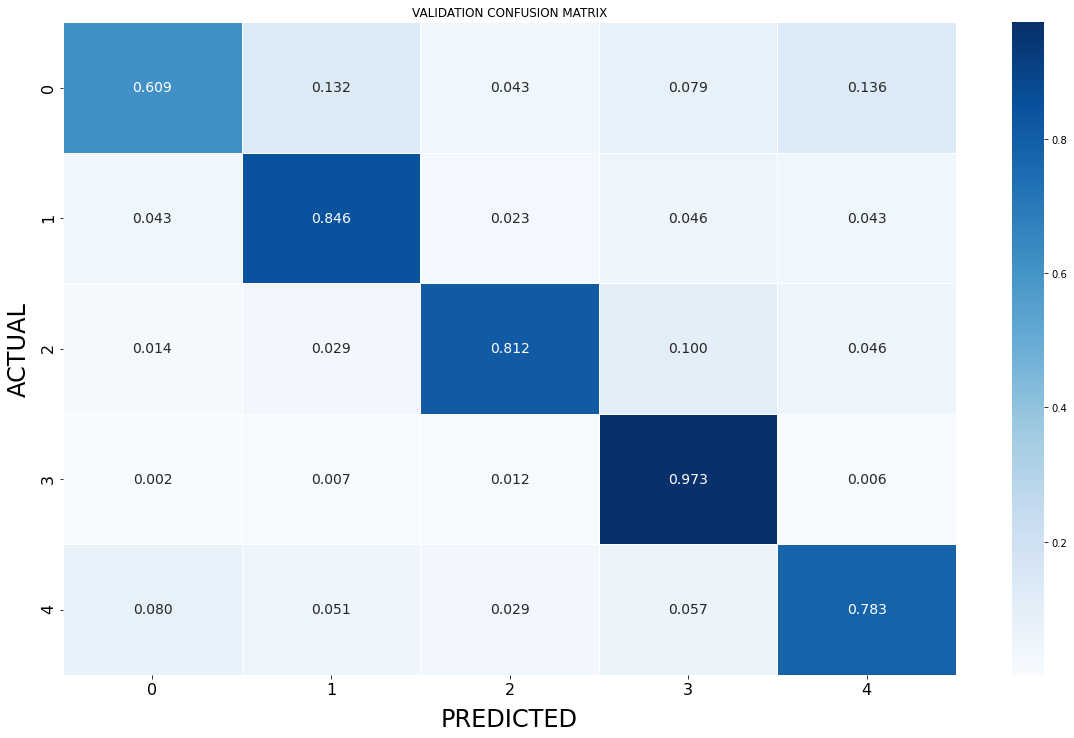

In [24]:
print(f'TRAINING FOR {EPOCHS} EPOCHS WITH BATCH SIZE {BATCH_SIZE}\n')
print(f'TRAIN IMAGES: {N_TRAIN_IMGS}, VAL IMAGES: {N_VAL_IMGS}\n')

augmentations_dic = dict({
    0: 'None',
    1: 'MixUp',
    2: 'CutMix',
    3: 'GridMask',
})

net_choices = dict({
    0: "Efficientnet",
    1: "ResNet"
})
    


augmentations = [2, 3] # only CutMix and GridMask is used
choice = 2   # choice can be 0 or 1 according to the dictionary given above

# MEAN_VAL_ACC = []
# fold = 0
# epochs = EPOCHS

for choice in [2]:
    MEAN_VAL_ACC = []
    fold = 0
    epochs = EPOCHS
    for idx, fold in enumerate(range(N_FOLDS)):
        # callbacks
        lr_callback_1 = tf.keras.callbacks.LearningRateScheduler(lambda epoch: lrfn(epoch, epochs=epochs), verbose=1)
    #     lr_callback_2 = tf.keras.callbacks.LearningRateScheduler(lrfn2, verbose = True)
    #     show_lr_schedule(epochs=epochs)

        # get the model
        model = get_model(choice)

        if idx is 0:
            # model summary
            model.summary()
            # compute and variable data types
            print(f'Compute dtype: {mixed_precision.global_policy().compute_dtype}')
            print(f'Variable dtype: {mixed_precision.global_policy().variable_dtype}')

        print('\n')
        print('*'*25, f'augmentations {augmentations}', '*'*25, '\n')
        print(f'fold: {fold}, epochs: {epochs}')
        print(' AND '.join([augmentations_dic.get(i) for i in augmentations]), '\n')

        train_dataset = get_train_dataset(bs=BATCH_SIZE, fold=fold, augmentations=augmentations)
        val_dataset = get_val_dataset(bs=BATCH_SIZE_VAL, fold=fold)

        history = model.fit(
            train_dataset,
            steps_per_epoch = N_TRAIN_IMGS // BATCH_SIZE,

            validation_data = val_dataset,
            validation_steps = N_VAL_IMGS // BATCH_SIZE_VAL,

            epochs = epochs,
            callbacks = [lr_callback_1],
            verbose=1
        )

        # add val accuracy to list
        MEAN_VAL_ACC.append(history.history['val_accuracy'][-1])

        # plot training histories
        plot_history_metric(history, 'loss')
        plot_history_metric(history, 'accuracy')
        plot_history_metric(history, 'top_2_accuracy')

        # show train and validation report
        show_validation_report_per_class(model, val_dataset, N_VAL_IMGS // BATCH_SIZE_VAL, 'VALIDATION', BATCH_SIZE_VAL)

        # save the model
        model.save_weights(f'model_fold_{fold}_weights.h5')
        model.save(f'model_{net_choices.get(choice)}_fold_{fold}.h5')

        del model, train_dataset, val_dataset
        gc.collect()